# Module 2 Lab: Implementing a Custom Weighted Distance Metric  
## Crusher Vibration and Temperature Similarity for Early Fault Review

## Scenario

You are supporting a **mining reliability team** responsible for monitoring a primary crusher.

The crusher is instrumented with:

- vibration RMS
- vibration peak
- vibration kurtosis
- bearing temperature

Each hour, a new sensor reading arrives. The business question is:

> **When a new reading arrives, which historical readings are most similar, and do those similar readings look like normal behaviour or early fault behaviour?**

This kind of similarity-based analysis can support:

- early warning review
- maintenance triage
- reliability investigation
- operational escalation decisions

A key challenge is that **not all sensor features are equally important**.

In many mechanical fault scenarios:

- vibration condition indicators change earlier
- temperature may lag behind the fault
- using plain distance without scaling or weighting can lead to misleading matches

This lab shows how to compare crusher operating states using:

1. plain Euclidean distance
2. scaled Euclidean distance
3. scaled + weighted Euclidean distance

## Key ideas

This lab introduces the following ideas:

- a **distance metric** measures how similar or different two observations are
- **Euclidean distance** measures straight-line difference across multiple features
- **scaling** makes distance comparisons fair when features use different units or ranges
- **weighted distance** lets you reflect domain priorities in the similarity calculation
- **nearest neighbours** are the historical readings most similar to a new reading
- domain knowledge can change what “similar” should mean operationally

## Learning goals

By the end of this lab, you should be able to:

1. load and inspect crusher sensor data
2. select the core features used for similarity comparison
3. compute Euclidean distance to find nearest historical readings
4. explain why scaling matters before using distance metrics
5. implement a custom weighted Euclidean distance in NumPy
6. verify weighted distance using a feature-scaling shortcut
7. compare how weighting changes nearest-neighbour behaviour
8. explain how weighting choices affect early fault review in mining operations


## How to use this notebook

Work through the notebook from top to bottom.

### Running the notebook

- Click inside a code cell.
- Press **Shift + Enter** to run it.
- Wait for the output to appear before moving on.

### Recommended workflow

1. Read the explanation above each code cell.
2. Run the code cell.
3. Review the output carefully.
4. Compare the output to the explanation.
5. Answer the reflection prompts in your own words.

### If something goes wrong

- Re-run the current cell.
- Make sure the earlier setup cells have already been run.
- Check that the dataset path is correct.
- If needed, restart the notebook kernel/runtime and run all cells again from the top.


## 1) Setup and load the dataset


In [1]:
# Import the Python tools used in this lab.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# StandardScaler is used to standardise the sensor features
# so that no single measurement dominates distance simply because of its unit scale.
from sklearn.preprocessing import StandardScaler

print("Environment ready ✅")

Environment ready ✅


In [2]:
# Load the crusher sensor dataset from the repository data folder.
# This dataset contains hourly crusher readings plus a teaching label called 'state'.

from pathlib import Path

DATA_URL = "https://raw.githubusercontent.com/albert-axi/mining-supervised-learning-workshop/main/data/crusher_sensor_mock_data.csv"
df = pd.read_csv(DATA_URL)

# Display the first few rows so we can confirm the structure.
display(df.head())

print("Shape:", df.shape)
print("Columns:", list(df.columns))


,timestamp,vibration_rms_mm_s,vibration_peak_mm_s,vibration_kurtosis,bearing_temp_c,throughput_tph,maintenance_window,state
0,2026-02-20 00:00:00,2.676,5.524,3.274,56.56,1382,0,normal
1,2026-02-20 01:00:00,2.340,5.692,2.933,59.58,1363,0,normal
2,2026-02-20 02:00:00,2.788,7.690,3.410,56.23,1478,0,normal
3,2026-02-20 03:00:00,2.835,5.625,3.263,57.45,1480,0,normal
4,2026-02-20 04:00:00,2.112,6.787,3.637,55.86,1553,0,normal


Shape: (200, 8)
Columns: ['timestamp', 'vibration_rms_mm_s', 'vibration_peak_mm_s', 'vibration_kurtosis', 'bearing_temp_c', 'throughput_tph', 'maintenance_window', 'state']


### What the dataset contains

This dataset includes:

- **timestamp**: when the reading was recorded
- **vibration_rms_mm_s**: overall vibration level
- **vibration_peak_mm_s**: peak vibration reading
- **vibration_kurtosis**: shape-based condition indicator
- **bearing_temp_c**: bearing temperature
- **throughput_tph**: crusher throughput in tonnes per hour
- **maintenance_window**: whether the reading occurred in a maintenance context
- **state**: teaching/demo label showing `normal` or `early_fault`

In real mining reliability workflows, you often do **not** have the final state label available in real time.  
In this lab, the label is included only so you can check whether the similarity logic behaves sensibly.


## 2) Select the core features for similarity


In [3]:
# Select the main condition-monitoring features used to compare crusher states.
# These focus on vibration and temperature because they are the core reliability signals.

features = [
    "vibration_rms_mm_s",
    "vibration_peak_mm_s",
    "vibration_kurtosis",
    "bearing_temp_c",
]

# Create the feature matrix X and the teaching labels y.
# X contains only the sensor values used in the distance calculations.
# y is used later only to evaluate whether the nearest neighbours look sensible.
X = df[features].values
y = df["state"].values

print("Feature matrix shape:", X.shape)
print("First feature row:", X[0])


Feature matrix shape: (200, 4)
First feature row: [ 2.676  5.524  3.274 56.56 ]


### Why these features were selected

These four features represent the most important condition indicators for this lab.

- the three vibration fields are often more sensitive to early mechanical change
- temperature is still useful, but may be slower-moving for some fault modes

Throughput and maintenance context can still matter operationally, but in this lab they are treated as supporting context rather than core similarity features.


## 3) Choose a new reading to investigate


In [4]:
# Pretend the most recent reading is the new incoming reading we want to investigate.
# All earlier rows are treated as historical reference data.

x_new = X[-1]       # newest reading
X_hist = X[:-1]     # historical readings
y_hist = y[:-1]

print("New reading values:")
for name, value in zip(features, x_new):
    print(f"{name}: {value}")


New reading values:
vibration_rms_mm_s: 3.342
vibration_peak_mm_s: 8.273
vibration_kurtosis: 4.966
bearing_temp_c: 61.12


In [5]:
# Show the full row for the incoming reading so it is easier to interpret.
display(df.tail(1))


,timestamp,vibration_rms_mm_s,vibration_peak_mm_s,vibration_kurtosis,bearing_temp_c,throughput_tph,maintenance_window,state
199,2026-02-28 07:00:00,3.342,8.273,4.966,61.12,1494,0,early_fault


### Why we split the data this way

This mimics a real operational use case:

- a new reading arrives now
- we compare it with historical readings
- we inspect the most similar historical cases
- we look for evidence of early fault behaviour among the closest matches


## 4) Baseline similarity with plain Euclidean distance


**Euclidean distance** measures straight-line difference across all selected features.

A smaller distance means the historical reading is more similar to the new reading.


In [6]:
# Compute the Euclidean distance between the incoming reading and every historical reading.
#
# Step by step:
# 1. X_hist - x_new calculates feature-by-feature differences.
# 2. np.linalg.norm(..., axis=1) combines those differences into one distance per row.

dists = np.linalg.norm(X_hist - x_new, axis=1)

# Sort the distances from smallest to largest and keep the 5 nearest neighbours.
nn_idx = np.argsort(dists)[:5]

# Display the nearest historical matches.
display(df.iloc[nn_idx][["timestamp"] + features + ["state"]])

print("Top 5 unscaled Euclidean distances:")
print(np.round(dists[nn_idx], 4))


,timestamp,vibration_rms_mm_s,vibration_peak_mm_s,vibration_kurtosis,bearing_temp_c,state
174,2026-02-27 06:00:00,3.606,8.508,4.867,61.04,early_fault
175,2026-02-27 07:00:00,3.512,8.561,4.795,61.61,early_fault
195,2026-02-28 03:00:00,3.522,8.041,5.382,60.63,early_fault
185,2026-02-27 17:00:00,2.803,8.329,5.259,61.75,early_fault
186,2026-02-27 18:00:00,2.835,8.407,5.779,61.13,early_fault


Top 5 unscaled Euclidean distances:
[0.3757 0.6174 0.7067 0.8811 0.9675]


### Reflection prompt

Look at the nearest neighbours returned by the plain Euclidean distance.

Questions to consider:

1. Do the closest matches look mostly normal or early fault?
2. Does the behaviour seem operationally sensible?
3. Could any one feature be dominating the distance because it has a larger numeric range?


## 5) Why scaling matters


Distance metrics are sensitive to feature units and numeric ranges.

In this dataset:

- temperature values are much larger numerically
- kurtosis values are smaller
- vibration values sit on yet another scale

Without scaling, one feature can dominate the result simply because of its number size rather than its true operational importance.


In [7]:
# Fit a StandardScaler on the historical data only.
# This transforms each feature so it has:
# - mean close to 0
# - standard deviation close to 1
#
# This makes the distance calculation more balanced across features.

scaler = StandardScaler()
X_hist_scaled = scaler.fit_transform(X_hist)

# Transform the new reading using the same fitted scaler.
x_new_scaled = scaler.transform([x_new])[0]

# Compute Euclidean distances again, now on the scaled values.
dists_scaled = np.linalg.norm(X_hist_scaled - x_new_scaled, axis=1)
nn_idx_scaled = np.argsort(dists_scaled)[:5]

display(df.iloc[nn_idx_scaled][["timestamp"] + features + ["state"]])

print("Top 5 scaled Euclidean distances:")
print(np.round(dists_scaled[nn_idx_scaled], 4))


,timestamp,vibration_rms_mm_s,vibration_peak_mm_s,vibration_kurtosis,bearing_temp_c,state
177,2026-02-27 09:00:00,3.462,8.344,5.184,62.19,early_fault
175,2026-02-27 07:00:00,3.512,8.561,4.795,61.61,early_fault
174,2026-02-27 06:00:00,3.606,8.508,4.867,61.04,early_fault
195,2026-02-28 03:00:00,3.522,8.041,5.382,60.63,early_fault
181,2026-02-27 13:00:00,3.394,9.206,5.413,60.76,early_fault


Top 5 scaled Euclidean distances:
[0.509  0.5291 0.6818 0.7124 0.8655]


### Teaching point

Scaling makes distance comparisons fairer.

After scaling, the model compares **relative deviation** rather than raw unit size.  
That usually gives a more balanced view of similarity across multiple sensors.


## 6) Implement a custom weighted Euclidean distance


Now we add domain knowledge.

Suppose reliability engineers tell you that:

- vibration RMS matters strongly
- vibration peak also matters strongly
- kurtosis matters, but slightly less
- temperature is still relevant, but less discriminative for some early fault modes

We can encode this by giving vibration features larger weights.


In [14]:
# Define custom feature weights in the same order as the features list.
#
# [vibration_rms_mm_s, vibration_peak_mm_s, vibration_kurtosis, bearing_temp_c]
weights = np.array(1.0, 1.0, 1.0, 4.0)

print("Weights:", weights)
print("Feature order:", features)


TypeError: array() takes from 1 to 2 positional arguments but 4 were given

In [15]:
# Compute weighted Euclidean distance on the scaled feature values.
#
# Formula:
# sqrt(sum(weight_i * (difference_i^2)))
#
# Why use scaled values first?
# Because weighting should reflect domain importance, not accidental unit size.

diff = X_hist_scaled - x_new_scaled
dists_weighted = np.sqrt(np.sum(weights * (diff ** 2), axis=1))

# Find the 5 nearest neighbours under the weighted distance.
nn_idx_weighted = np.argsort(dists_weighted)[:5]

display(df.iloc[nn_idx_weighted][["timestamp"] + features + ["state"]])

print("Top 5 scaled + weighted Euclidean distances:")
print(np.round(dists_weighted[nn_idx_weighted], 4))


,timestamp,vibration_rms_mm_s,vibration_peak_mm_s,vibration_kurtosis,bearing_temp_c,state
177,2026-02-27 09:00:00,3.462,8.344,5.184,62.19,early_fault
175,2026-02-27 07:00:00,3.512,8.561,4.795,61.61,early_fault
195,2026-02-28 03:00:00,3.522,8.041,5.382,60.63,early_fault
174,2026-02-27 06:00:00,3.606,8.508,4.867,61.04,early_fault
181,2026-02-27 13:00:00,3.394,9.206,5.413,60.76,early_fault


Top 5 scaled + weighted Euclidean distances:
[0.7151 0.8687 1.1032 1.174  1.3854]


### What this weighting means operationally

These weights express a reliability preference:

- be more sensitive to vibration-led change
- be less dominated by temperature
- pull nearest neighbours toward historical cases with similar vibration signatures

This is useful when early mechanical faults tend to appear in vibration features before temperature rises clearly.


## 7) Verify weighted distance using a practical shortcut


In [16]:
# Weighted Euclidean distance can also be reproduced by scaling each feature by sqrt(weight)
# and then using normal Euclidean distance.
#
# This is useful because it shows the weighted formula is mathematically consistent.

X_hist_weighted = X_hist_scaled * np.sqrt(weights)
x_new_weighted = x_new_scaled * np.sqrt(weights)

dists_weighted_check = np.linalg.norm(X_hist_weighted - x_new_weighted, axis=1)

print("Do both weighted-distance methods match?")
print(np.allclose(dists_weighted, dists_weighted_check))


Do both weighted-distance methods match?
True


## 8) Compare the three approaches


In [17]:
# Create a simple helper function to measure how many of the nearest neighbours
# belong to the 'early_fault' teaching label.

def early_fault_share(indices):
    return np.mean(df.iloc[indices]["state"].values == "early_fault")

print("Unscaled Euclidean top-5 early_fault share:", round(early_fault_share(nn_idx), 3))
print("Scaled Euclidean top-5 early_fault share:", round(early_fault_share(nn_idx_scaled), 3))
print("Scaled + Weighted top-5 early_fault share:", round(early_fault_share(nn_idx_weighted), 3))


Unscaled Euclidean top-5 early_fault share: 1.0
Scaled Euclidean top-5 early_fault share: 1.0
Scaled + Weighted top-5 early_fault share: 1.0


In [18]:
# Summarise the neighbour comparison in one table.

comparison = pd.DataFrame({
    "method": [
        "Unscaled Euclidean",
        "Scaled Euclidean",
        "Scaled + Weighted Euclidean",
    ],
    "early_fault_share_top5": [
        early_fault_share(nn_idx),
        early_fault_share(nn_idx_scaled),
        early_fault_share(nn_idx_weighted),
    ]
})

display(comparison)


,method,early_fault_share_top5
0,Unscaled Euclidean,1.0
1,Scaled Euclidean,1.0
2,Scaled + Weighted Euclidean,1.0


### Interpretation guide

If the incoming reading is drifting into early-fault territory, a good similarity setup should tend to retrieve more historical `early_fault` examples among the nearest neighbours.

This does **not** prove the method is perfect, but it gives a useful teaching signal about whether the similarity logic is aligned with operational goals.


## 9) Visualise the sensor ranges


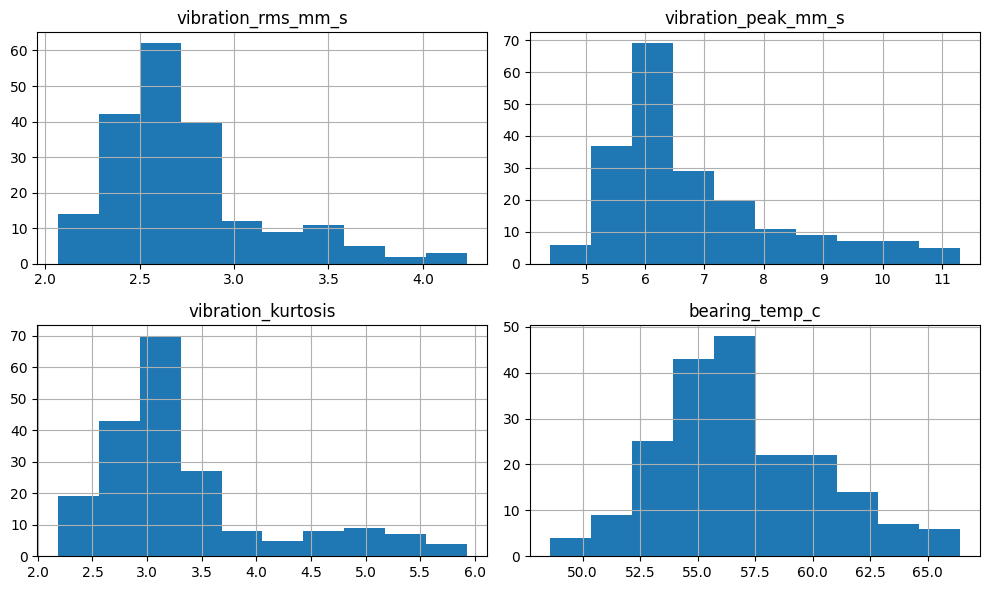

In [19]:
# Plot the four sensor features to show why scaling is important.

df[features].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()


## 10) Quick challenge


Try changing the weights and re-running the weighted-distance cells.

### Suggested experiments

1. **Temperature-heavy weighting**
   - `weights_temp_heavy = np.array([1.0, 1.0, 1.0, 4.0])`

2. **Vibration-dominant weighting**
   - `weights_vib_heavy = np.array([4.0, 4.0, 2.0, 1.0])`

### Questions to answer

- Which setting seems best for early detection?
- Which setting might reduce false alarms?
- Which setting would a reliability engineer prefer?
- Which setting might operations prefer if unnecessary inspections are costly?


## 11) Optional extension


Write a short response in a new Markdown cell:

1. Should feature weights be set by engineering judgment, by historical data analysis, or by both?

Both. Also it's good to be aware if two feature sets are actually identical data as this can introduce bias.


2. What governance step should exist before changing weights in a production monitoring workflow?

Record hyperparameter changes. That was model performance can be tracked.


3. How could this similarity approach be integrated into a crusher reliability dashboard?
Dimension reduction; a similarity identification layer can take lots of datapoints and condense the end result; cocern or of no concern for the end user





## Wrap-up

You have completed a mining reliability lab on custom distance metrics.

### What you covered

- loading crusher sensor data
- selecting condition-monitoring features
- using Euclidean distance for similarity
- scaling features before distance calculations
- implementing a custom weighted Euclidean distance
- validating the weighted formulation
- comparing how distance choices affect nearest neighbours

### Practical mining connection

This kind of approach can support:

- early fault review
- similar-event retrieval
- maintenance triage
- explainable condition-monitoring workflows

A key lesson is that **distance defines what “similar” means**.  
Scaling and weighting let you make that definition more aligned with mining reliability priorities.
